# Úkol 3

Zpracovat soubor 'titanic.csv' a odpovědět na otázky:

1. zavisí přežití na třídě, ve které cestující cestoval?
2. závisí přežití na pohlaví pasažera?
3.  zavisí přežití pasažéra na jeho věku?
4. závisí přežití na místu nalodění?

Doporučený postup:
- načtení dat
- vyčištění dat
  - nastavit správné datové typy
  - pořešit chybějící data
  - pořešit extrémní hodnoty
- základní popisná statistika
  - tabulky
  - grafy (histogram, boxplot,...)
- zpracování (odpovědět na výše uvedené otázky)
  - tabulky
  - grafy

## Načtení dat

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.core.pylabtools import figsize

df = pd.read_csv('./data/titanic.csv',
                 usecols=lambda x: not x.startswith('zero'))

df.rename(columns={'2urvived': 'Survived'}, inplace=True)

df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Passengerid  1309 non-null   int64  
 1   Age          1309 non-null   float64
 2   Fare         1309 non-null   float64
 3   Sex          1309 non-null   int64  
 4   sibsp        1309 non-null   int64  
 5   Parch        1309 non-null   int64  
 6   Pclass       1309 non-null   int64  
 7   Embarked     1307 non-null   float64
 8   Survived     1309 non-null   int64  
dtypes: float64(3), int64(6)
memory usage: 92.2 KB


,Passengerid,Age,Fare,Sex,sibsp,Parch,Pclass,Embarked,Survived
0,1,22.0,7.2500,0,1,0,3,2.0,0
1,2,38.0,71.2833,1,1,0,1,0.0,1
2,3,26.0,7.9250,1,0,0,3,2.0,1
3,4,35.0,53.1000,1,1,0,1,2.0,1
4,5,35.0,8.0500,0,0,0,3,2.0,0


## Čištění dat
### Chybějící data

In [11]:
print(df.isnull().sum())

Passengerid    0
Age            0
Fare           0
Sex            0
sibsp          0
Parch          0
Pclass         0
Embarked       2
Survived       0
dtype: int64


Žádná chybějící data

### Extrémní hodnoty

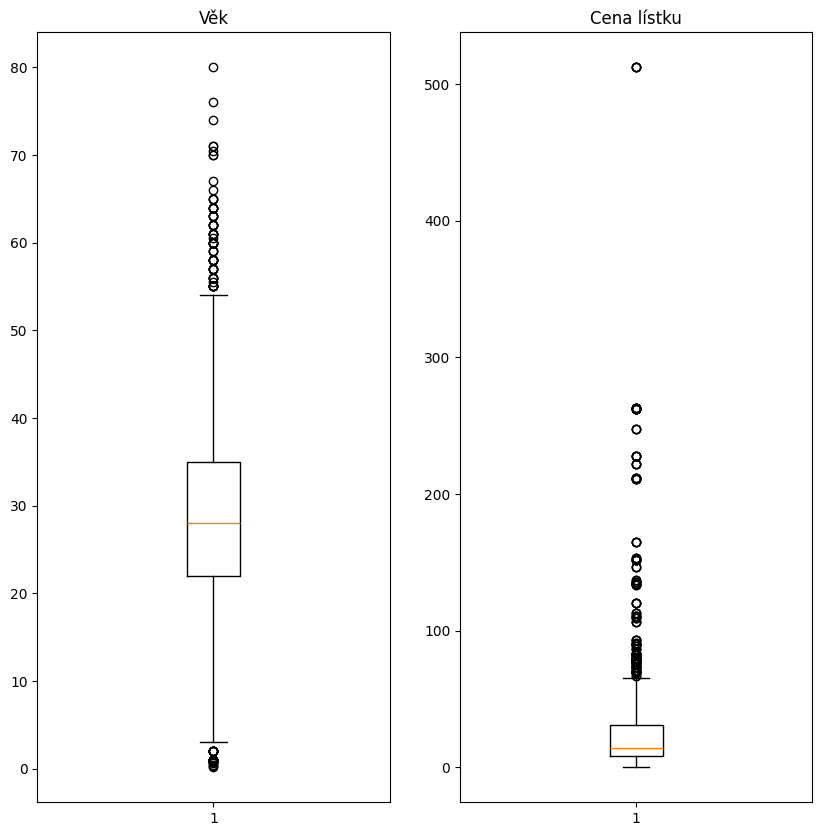

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(10, 10), sharey=False)

ax[0].boxplot(df['Age'])
ax[0].set_title('Věk')

ax[1].boxplot(df['Fare'])
ax[1].set_title('Cena lístku')

plt.show()

U proměnné Age i Fare máme odlehlé hodnoty, ale jsou to reálné hodnoty, nebudeme je měnit.

## Popisná statistika

In [17]:
df.describe()

,Passengerid,Age,Fare,Sex,sibsp,Parch,Pclass,Embarked,Survived
count,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1307.000000,1309.000000
mean,655.000000,29.503186,33.281086,0.355997,0.498854,0.385027,2.294882,1.492731,0.261268
std,378.020061,12.905241,51.741500,0.478997,1.041658,0.865560,0.837836,0.814626,0.439494
min,1.000000,0.170000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,328.000000,22.000000,7.895800,0.000000,0.000000,0.000000,2.000000,1.000000,0.000000
50%,655.000000,28.000000,14.454200,0.000000,0.000000,0.000000,3.000000,2.000000,0.000000
75%,982.000000,35.000000,31.275000,1.000000,1.000000,0.000000,3.000000,2.000000,1.000000
max,1309.000000,80.000000,512.329200,1.000000,8.000000,9.000000,3.000000,2.000000,1.000000


### Věk

<Axes: xlabel='Age', ylabel='Density'>

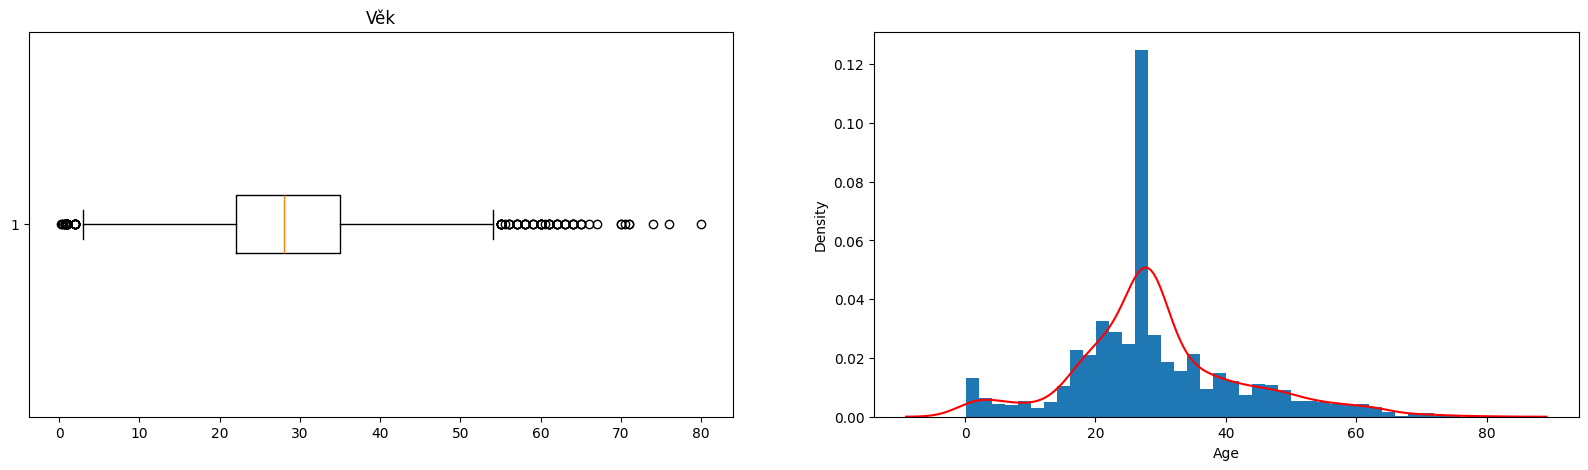

In [30]:
import seaborn as sns

fig, ax = plt.subplots(1, 2, figsize=(20, 5), sharey=False)

ax[0].boxplot(df['Age'], vert=False)
ax[0].set_title('Věk')

ax[1].hist(df['Age'], bins=40, density=True)
sns.kdeplot(df['Age'], color='red', ax=ax[1])

### Fare

<Axes: xlabel='Fare', ylabel='Density'>

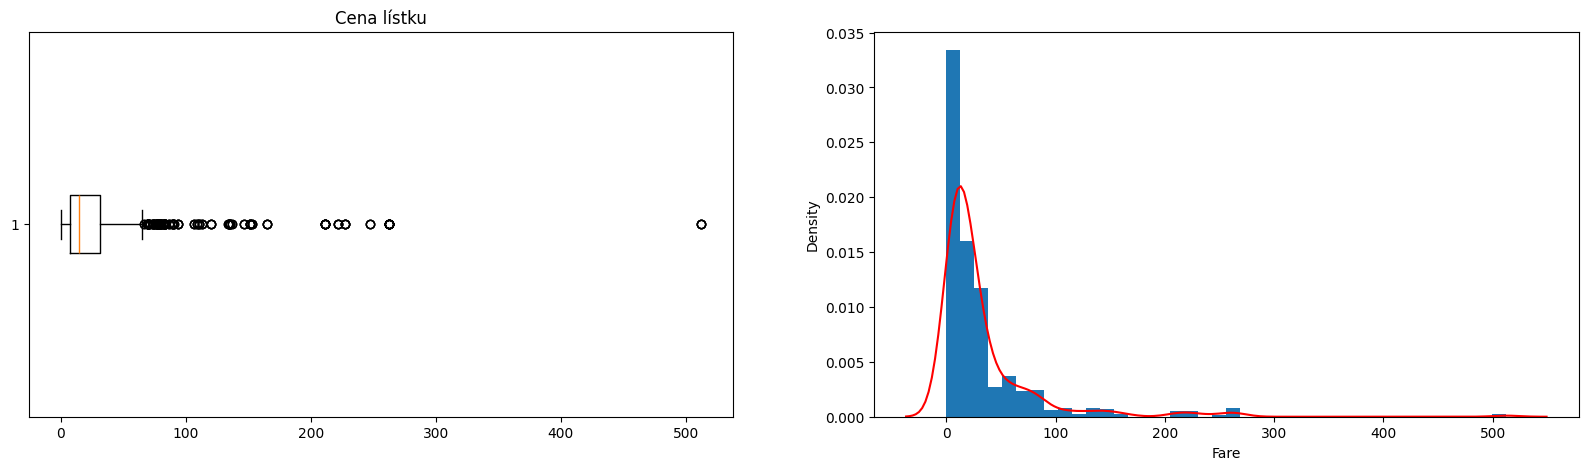

In [31]:
fig, ax = plt.subplots(1, 2, figsize=(20, 5), sharey=False)

ax[0].boxplot(df['Fare'], vert=False)
ax[0].set_title('Cena lístku')

ax[1].hist(df['Fare'], bins=40, density=True)
sns.kdeplot(df['Fare'], color='red', ax=ax[1])

### Pohlaví

Sex
0    843
1    466
Name: count, dtype: int64

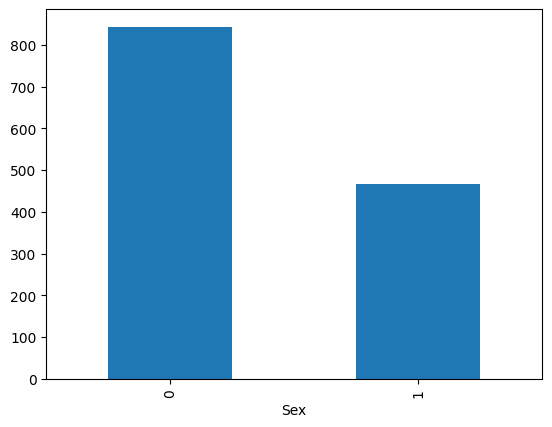

In [37]:
sex_counts = df['Sex'].value_counts()
sex_counts.plot(kind='bar')
sex_counts

### Třída

Pclass
1    323
2    277
3    709
Name: count, dtype: int64

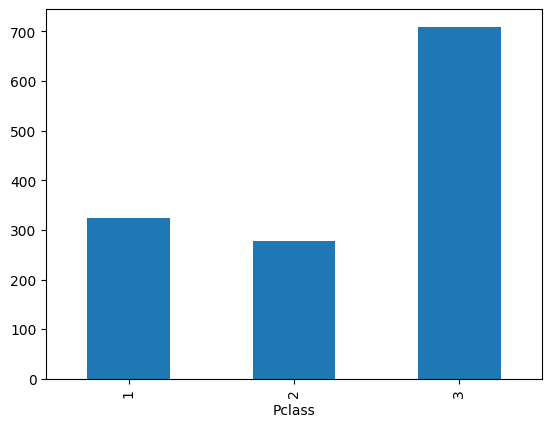

In [39]:
class_counts = df['Pclass'].value_counts().sort_index()
class_counts.plot(kind='bar')
class_counts

### Místo nalodění

Embarked
0.0    270
1.0    123
2.0    914
Name: count, dtype: int64

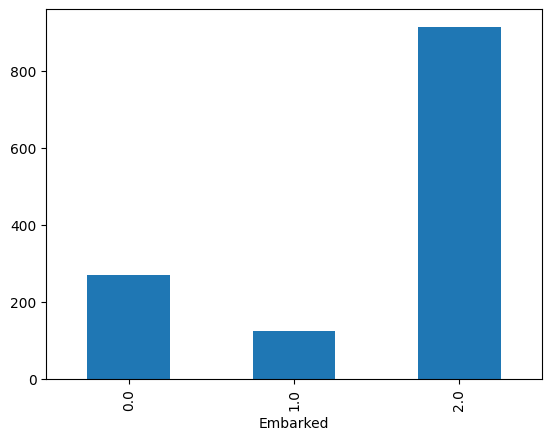

In [40]:
embarked_counts = df['Embarked'].value_counts().sort_index()
embarked_counts.plot(kind='bar')
embarked_counts

### Přežití

Survived
0    967
1    342
Name: count, dtype: int64

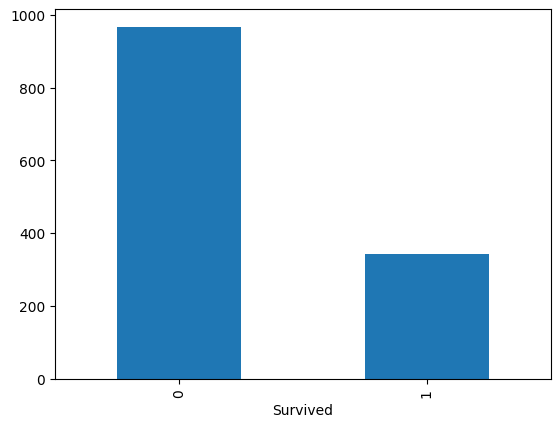

In [41]:
survived_counts = df['Survived'].value_counts().sort_index()
survived_counts.plot(kind='bar')
survived_counts

## Zpracování dat

### zavisí přežití na třídě, ve které cestující cestoval?


Pclass      1    2    3
Survived               
0         187  190  590
1         136   87  119


<Axes: xlabel='Survived'>

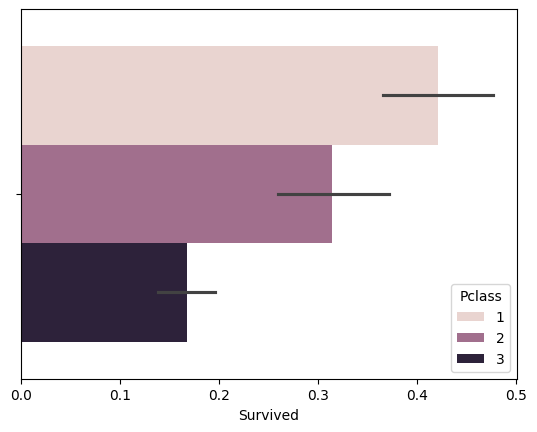

In [45]:
survived_class = pd.crosstab(df['Survived'], df['Pclass'])
print(survived_class)

sns.barplot(x=df['Survived'], hue=df['Pclass'])


        Survived
Pclass          
1       0.421053
2       0.314079
3       0.167842


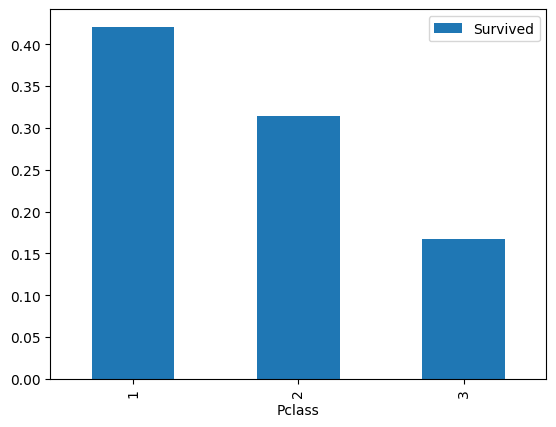

In [52]:
survived_class_pivot = df.pivot_table(
    index='Pclass',
    values='Survived',
)
print(survived_class_pivot)
survived_class_pivot.plot.bar()
plt.show()

### závisí přežití na pohlaví pasažera?


     Survived
Sex          
0      0.1293
1      0.5000


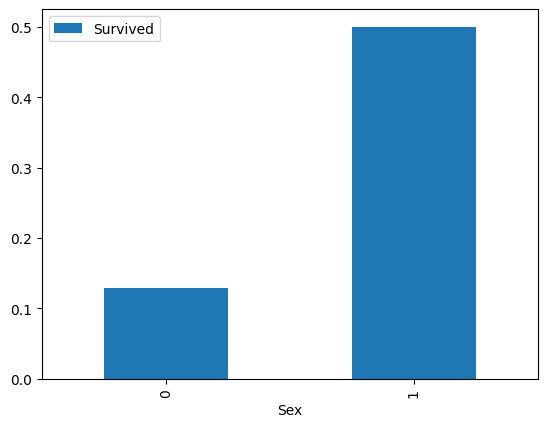

In [53]:
survived_sex_pivot = df.pivot_table(
    index='Sex',
    values='Survived',
)
print(survived_sex_pivot)
survived_sex_pivot.plot.bar()
plt.show()

### zavisí přežití pasažéra na jeho věku?


          count       mean        std   min   25%   50%   75%   max
Survived                                                           
0         967.0  29.931748  12.566829  0.17  23.0  28.0  35.0  76.0
1         342.0  28.291433  13.764425  0.42  21.0  28.0  35.0  80.0


<Axes: xlabel='Survived', ylabel='Age'>

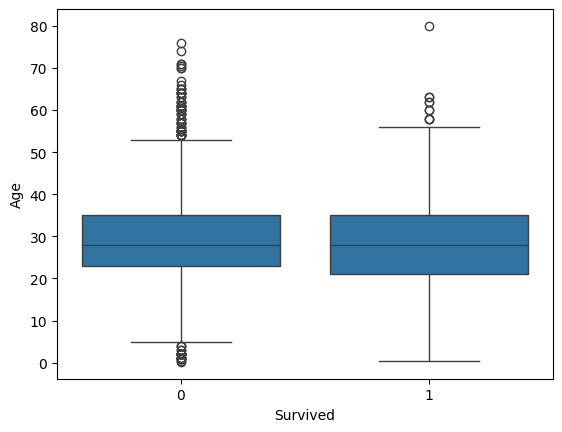

In [56]:
survived_age_pivot = df.groupby('Survived')['Age'].describe()
print(survived_age_pivot)

sns.boxplot(data=df, x='Survived', y='Age')

### závisí přežití na místu nalodění?

          Survived
Embarked          
0.0       0.344444
1.0       0.243902
2.0       0.237418


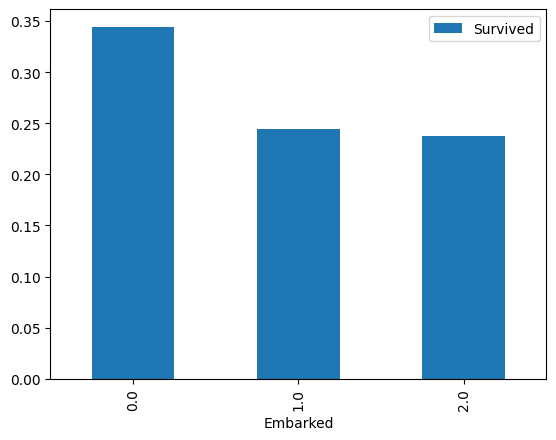

In [57]:
survived_embarked_pivot = df.pivot_table(
    index='Embarked',
    values='Survived',
)
print(survived_embarked_pivot)
survived_embarked_pivot.plot.bar()
plt.show()